## Find prob threshold for experiments 7,8,9

In [1]:
### Imports
# Standard library imports
import json
import os
import shutil
import logging
import sys

# Third-party imports
# Data handling
import numpy as np
import pandas as pd

# Image I/O and processing
import tifffile as tiff
from nd2reader import ND2Reader
from skimage.morphology import remove_small_objects

# Deep learning and segmentation
from csbdeep.utils import Path, normalize
from stardist import (
    fill_label_holes,
    random_label_cmap,
    calculate_extents,
    gputools_available,
)
from stardist.matching import matching, matching_dataset
from stardist.models import Config2D, StarDist2D, StarDistData2D
from tensorflow.keras.utils import Sequence

# Tracking
import btrack
from btrack.constants import BayesianUpdates

# Visualization
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# Utilities
from tqdm.notebook import tqdm

from datetime import datetime

import pickle

2025-04-16 20:28:23.651034: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744828104.022160 4021573 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744828104.189668 4021573 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-16 20:28:25.096291: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
USE_GPU = True

In [3]:
# Load data 
axis_norm = (0,1)  
imgs = tiff.imread('/mnt/imaging.data/PertzLab/apoDetection/TIFFs/Exp05_WellA1_Site02.tif')
imgs = imgs[:100]
imgs_normal = np.asarray([normalize(img, 1, 99.8, axis=axis_norm) for img in tqdm(imgs)])

  0%|          | 0/100 [00:00<?, ?it/s]

In [4]:
# Set up GT_mask prediction with stardist
if USE_GPU:
    import gputools
    from csbdeep.utils.tf import limit_gpu_memory
    limit_gpu_memory(None, allow_growth=True)
model = StarDist2D.from_pretrained("2D_versatile_fluo")    # Load standard model to create GT
  # for normalization

If you want to compute separable approximations, please install it with
pip install scikit-tensor-py3
Found model '2D_versatile_fluo' for 'StarDist2D'.


I0000 00:00:1744828128.917067 4021573 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21775 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:81:00.0, compute capability: 8.9


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


In [5]:
preds = []
for prob_thr in [0.3, 0.4, 0.5, 0.6]:
    gt = []
    details = []
    for x in tqdm(imgs_normal, desc="Segmenting"):
        labels, det = model.predict_instances(x, n_tiles=model._guess_n_tiles(x), show_tile_progress=False, prob_thresh=prob_thr)
        gt.append(labels)
        details.append(det)
    gt = np.asarray(gt)
    preds.append(gt)

Segmenting:   0%|          | 0/100 [00:00<?, ?it/s]

functional.py (237): The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 256, 256, 1))
I0000 00:00:1744828136.332700 4021744 service.cc:148] XLA service 0x77d54800b160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744828136.332723 4021744 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-04-16 20:28:56.410161: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744828136.580646 4021744 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1744828138.773487 4021744 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
functional.py (237): The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Te

Segmenting:   0%|          | 0/100 [00:00<?, ?it/s]

Segmenting:   0%|          | 0/100 [00:00<?, ?it/s]

Segmenting:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, len(preds))
for i, pred in enumerate(preds):
    ax[i].imshow(pred[0])  # Show first image's predictions
    ax[i].set_title(f"prob_thresh={0.3 + i*0.1}")
plt.show()

In [8]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

def create_segmentation_viewer(imgs_normal, preds, prob_thresholds=[0.3, 0.4, 0.5, 0.6]):
    """
    Create an interactive viewer for comparing segmentation results across different probability thresholds.
    
    Parameters:
    -----------
    imgs_normal : numpy.ndarray
        Normalized images with shape (t, height, width)
    preds : list of numpy.ndarray
        List of segmentation predictions for different thresholds,
        each with shape (t, height, width)
    prob_thresholds : list
        List of probability thresholds used for segmentation
    """
    # Create a random colormap for segmentation labels
    np.random.seed(42)  # For reproducible colors
    n_colors = 256
    colors = np.random.rand(n_colors, 4)
    colors[:, 3] = 0.5  # Alpha for overlay
    colors[0] = [0, 0, 0, 0]  # Background is transparent
    random_cmap = ListedColormap(colors)
    
    # Time slider
    max_t = min(len(imgs_normal), preds[0].shape[0]) - 1
    t_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_t,
        step=1,
        description='Time:',
        continuous_update=False
    )

    # Options for visualization
    alpha_slider = widgets.FloatSlider(
        value=0.5,
        min=0,
        max=1.0,
        step=0.05,
        description='Opacity:',
        continuous_update=False
    )
    
    show_original = widgets.Checkbox(
        value=True,
        description='Show original image',
    )
    
    # Create the output widget
    out = widgets.Output()
    
    # Layout settings
    fig_height = 12
    fig_width = 15
    
    # Function to update the plot
    def update_plot(t=0, alpha=0.5, show_img=True):
        with out:
            out.clear_output(wait=True)
            
            fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height))
            axes = axes.flatten()
            
            # Get min and max for consistent color scaling
            vmin = np.min(imgs_normal[t])
            vmax = np.max(imgs_normal[t])
            
            for i, (pred, prob_thr) in enumerate(zip(preds, prob_thresholds)):
                ax = axes[i]
                
                # Show original image if selected
                if show_img:
                    ax.imshow(imgs_normal[t], cmap='gray', vmin=vmin, vmax=vmax)
                
                # Overlay segmentation mask
                if t < pred.shape[0]:
                    mask = pred[t]
                    ax.imshow(mask, cmap=random_cmap, alpha=alpha)
                
                # Set title and remove axes
                ax.set_title(f'Threshold: {prob_thr}', fontsize=12)
                ax.axis('off')
            
            plt.tight_layout()
            plt.show()
    
    # Connect the widgets to the plot update function
    def on_change(change):
        update_plot(t_slider.value, alpha_slider.value, show_original.value)
    
    t_slider.observe(on_change, names='value')
    alpha_slider.observe(on_change, names='value')
    show_original.observe(on_change, names='value')
    
    # Create controls layout
    controls = widgets.HBox([t_slider, alpha_slider, show_original])
    
    # Initial plot
    update_plot(t_slider.value, alpha_slider.value, show_original.value)
    
    # Display widgets and plot
    display(widgets.VBox([controls, out]))

# Example usage:
create_segmentation_viewer(imgs_normal, preds)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from skimage import measure
from scipy import ndimage
from tqdm.notebook import tqdm

def analyze_object_sizes(preds, prob_thresholds=[0.3, 0.4, 0.5, 0.6], min_sizes_to_test=[50, 100, 200, 300, 500]):
    """
    Analyze object sizes in segmentation results and visualize the impact of size filtering.
    
    Parameters:
    -----------
    preds : list of numpy.ndarray
        List of segmentation predictions for different thresholds,
        each with shape (t, height, width)
    prob_thresholds : list
        List of probability thresholds used for segmentation
    min_sizes_to_test : list
        List of minimum object sizes to evaluate
    """
    
    all_sizes = []
    size_stats = []
    
    # Extract sizes of all objects across all frames for each segmentation
    for i, (pred, prob_thr) in enumerate(zip(preds, prob_thresholds)):
        print(f"Processing segmentation with threshold {prob_thr}...")
        pred_sizes = []
        
        # Process all frames
        for t in tqdm(range(pred.shape[0])):
            # Get labels from current frame
            labels = pred[t]
            
            # Get region properties
            regions = measure.regionprops(labels)
            
            # Extract areas
            for region in regions:
                pred_sizes.append(region.area)
        
        all_sizes.append(pred_sizes)
        
        # Calculate statistics
        if pred_sizes:
            size_stats.append({
                'threshold': prob_thr,
                'min': min(pred_sizes),
                'max': max(pred_sizes),
                'mean': np.mean(pred_sizes),
                'median': np.median(pred_sizes),
                'std': np.std(pred_sizes),
                'count': len(pred_sizes)
            })
        else:
            size_stats.append({
                'threshold': prob_thr,
                'min': 0, 'max': 0, 'mean': 0,
                'median': 0, 'std': 0, 'count': 0
            })
    
    # Convert stats to DataFrame
    stats_df = pd.DataFrame(size_stats)
    display(stats_df)
    
    # Create interactive visualization
    def create_size_histogram():
        # Threshold selector
        threshold_selector = widgets.Dropdown(
            options=list(enumerate(prob_thresholds)),
            value=0,
            description='Threshold:',
        )
        
        # Output widget
        out = widgets.Output()
        
        # Function to update plot
        def update_plot(threshold_idx):
            sizes = all_sizes[threshold_idx]
            with out:
                out.clear_output(wait=True)
                
                if not sizes:
                    print("No objects detected with this threshold.")
                    return
                
                # Create figure with subplots
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
                
                # Histogram of object sizes
                bins = np.logspace(np.log10(max(1, min(sizes))), np.log10(max(sizes)), 50)
                ax1.hist(sizes, bins=bins, alpha=0.7)
                ax1.set_xscale('log')
                ax1.set_title(f'Object Size Distribution (Threshold {prob_thresholds[threshold_idx]})')
                ax1.set_xlabel('Object Size (pixels)')
                ax1.set_ylabel('Count')
                ax1.grid(True, alpha=0.3)
                
                # Add vertical lines for size thresholds
                colors = plt.cm.tab10(np.linspace(0, 1, len(min_sizes_to_test)))
                for i, min_size in enumerate(min_sizes_to_test):
                    ax1.axvline(x=min_size, color=colors[i], linestyle='--', 
                                label=f'Min Size = {min_size}')
                ax1.legend()
                
                # Objects retained after size filtering
                retained = []
                for min_size in min_sizes_to_test:
                    retained.append(sum(s >= min_size for s in sizes) / len(sizes) * 100)
                
                ax2.bar(range(len(min_sizes_to_test)), retained, color=colors)
                ax2.set_xticks(range(len(min_sizes_to_test)))
                ax2.set_xticklabels([f'{s}' for s in min_sizes_to_test])
                ax2.set_ylim(0, 100)
                ax2.set_title('Percentage of Objects Retained After Size Filtering')
                ax2.set_xlabel('Minimum Object Size (pixels)')
                ax2.set_ylabel('Percentage Retained')
                
                for i, r in enumerate(retained):
                    ax2.text(i, r + 2, f'{r:.1f}%', ha='center')
                
                plt.tight_layout()
                plt.show()
                
                # Display table with size distribution details
                size_ranges = [
                    (0, 50), (50, 100), (100, 200), (200, 300), 
                    (300, 500), (500, 1000), (1000, np.inf)
                ]
                
                counts = []
                percentages = []
                
                for low, high in size_ranges:
                    count = sum(low <= s < high for s in sizes)
                    counts.append(count)
                    percentages.append(count / len(sizes) * 100)
                
                range_labels = [
                    f"{low}-{high}" if high != np.inf else f"{low}+" 
                    for low, high in size_ranges
                ]
                
                dist_df = pd.DataFrame({
                    'Size Range': range_labels,
                    'Count': counts,
                    'Percentage': [f'{p:.2f}%' for p in percentages]
                })
                
                display(dist_df)
        
        # Connect the widget to the update function
        def on_threshold_change(change):
            update_plot(change.new)
        
        threshold_selector.observe(on_threshold_change, names='value')
        
        # Initial plot
        update_plot(threshold_selector.value)
        
        # Display widgets and plot
        display(widgets.VBox([threshold_selector, out]))
    
    # Create visualization for size filtering impact across frames
    def create_time_impact_visualizer():
        # Control widgets
        threshold_selector = widgets.Dropdown(
            options=list(enumerate(prob_thresholds)),
            value=0,
            description='Threshold:',
        )
        
        size_selector = widgets.Dropdown(
            options=list(enumerate(min_sizes_to_test)),
            value=2,  # Default to 200px threshold
            description='Min Size:',
        )
        
        # Output widget
        out = widgets.Output()
        
        # Function to update plot
        def update_plot(threshold_idx, size_idx):
            pred = preds[threshold_idx]
            min_size = min_sizes_to_test[size_idx]
            
            with out:
                out.clear_output(wait=True)
                
                # Calculate statistics per frame
                frame_counts = []
                frame_removed = []
                frame_mean_sizes = []
                
                for t in range(pred.shape[0]):
                    # Get labels from current frame
                    labels = pred[t]
                    
                    # Count objects and sizes before filtering
                    regions = measure.regionprops(labels)
                    original_count = len(regions)
                    
                    # Skip frames with no objects
                    if original_count == 0:
                        frame_counts.append(0)
                        frame_removed.append(0)
                        frame_mean_sizes.append(0)
                        continue
                    
                    # Calculate mean size
                    sizes = [r.area for r in regions]
                    frame_mean_sizes.append(np.mean(sizes))
                    
                    # Apply size filtering
                    filtered_mask = remove_small_objects(labels > 0, min_size=min_size)
                    filtered_labels = measure.label(filtered_mask)
                    filtered_count = len(measure.regionprops(filtered_labels))
                    
                    frame_counts.append(original_count)
                    frame_removed.append(original_count - filtered_count)
                
                # Create figure with subplots
                fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))
                
                # Plot object count per frame
                frames = np.arange(len(frame_counts))
                ax1.plot(frames, frame_counts, 'b-', linewidth=2, label='All Objects')
                ax1.plot(frames, [c - r for c, r in zip(frame_counts, frame_removed)], 
                         'g-', linewidth=2, label=f'Objects ≥ {min_size}px')
                ax1.fill_between(frames, frame_counts, 
                                [c - r for c, r in zip(frame_counts, frame_removed)],
                                color='r', alpha=0.3, label=f'Objects < {min_size}px')
                ax1.set_title(f'Object Count per Frame (Threshold {prob_thresholds[threshold_idx]})')
                ax1.set_xlabel('Frame')
                ax1.set_ylabel('Object Count')
                ax1.grid(True, alpha=0.3)
                ax1.legend()
                
                # Plot percentage of objects removed per frame
                removal_pct = [r/c*100 if c > 0 else 0 for r, c in zip(frame_removed, frame_counts)]
                ax2.plot(frames, removal_pct, 'r-', linewidth=2)
                ax2.axhline(y=np.mean(removal_pct), color='k', linestyle='--', 
                           label=f'Mean: {np.mean(removal_pct):.1f}%')
                ax2.set_title(f'Percentage of Objects Removed by Size Filter (< {min_size}px)')
                ax2.set_xlabel('Frame')
                ax2.set_ylabel('% Removed')
                ax2.set_ylim(0, 100)
                ax2.grid(True, alpha=0.3)
                ax2.legend()
                
                # Plot mean object size per frame
                ax3.plot(frames, frame_mean_sizes, 'b-', linewidth=2)
                ax3.axhline(y=np.mean(frame_mean_sizes), color='k', linestyle='--',
                           label=f'Mean: {np.mean(frame_mean_sizes):.1f}px')
                ax3.axhline(y=min_size, color='r', linestyle='--',
                           label=f'Filter: {min_size}px')
                ax3.set_title('Mean Object Size per Frame')
                ax3.set_xlabel('Frame')
                ax3.set_ylabel('Mean Size (pixels)')
                ax3.grid(True, alpha=0.3)
                ax3.legend()
                
                plt.tight_layout()
                plt.show()
                
                # Display summary statistics
                if sum(frame_counts) > 0:
                    print(f"Summary statistics for threshold {prob_thresholds[threshold_idx]} with {min_size}px size filter:")
                    print(f"Total objects: {sum(frame_counts)}")
                    print(f"Objects removed: {sum(frame_removed)} ({sum(frame_removed)/sum(frame_counts)*100:.1f}%)")
                    print(f"Objects retained: {sum(frame_counts) - sum(frame_removed)} ({(1-sum(frame_removed)/sum(frame_counts))*100:.1f}%)")
                    print(f"Mean object size: {np.mean(frame_mean_sizes):.1f}px")
                else:
                    print("No objects detected in these frames.")
        
        # Connect the widgets to the update function
        def on_change(change):
            update_plot(threshold_selector.value, size_selector.value)
        
        threshold_selector.observe(on_change, names='value')
        size_selector.observe(on_change, names='value')
        
        # Initial plot
        update_plot(threshold_selector.value, size_selector.value)
        
        # Display widgets and plot
        controls = widgets.HBox([threshold_selector, size_selector])
        display(widgets.VBox([controls, out]))
    
    # Create tabs for different visualizations
    tab_contents = [
        widgets.Output(),
        widgets.Output()
    ]
    
    tabs = widgets.Tab(children=tab_contents)
    tabs.set_title(0, 'Size Distribution')
    tabs.set_title(1, 'Time Series Analysis')
    
    display(tabs)
    
    with tab_contents[0]:
        create_size_histogram()
    
    with tab_contents[1]:
        create_time_impact_visualizer()

def test_size_filtering(preds, prob_thresholds=[0.3, 0.4, 0.5, 0.6], min_size=200):
    """
    Visualize the effect of size filtering on a specific frame from each segmentation.
    
    Parameters:
    -----------
    preds : list of numpy.ndarray
        List of segmentation predictions for different thresholds
    prob_thresholds : list
        List of probability thresholds used for segmentation
    min_size : int
        Minimum object size for filtering
    """
    # Frame selector
    frame_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=preds[0].shape[0] - 1,
        step=1,
        description='Frame:',
        continuous_update=False
    )
    
    # Size threshold slider
    size_slider = widgets.IntSlider(
        value=min_size,
        min=0,
        max=1000,
        step=10,
        description='Min Size:',
        continuous_update=False
    )
    
    # Output widget
    out = widgets.Output()
    
    # Function to update the plot
    def update_plot(t, min_size):
        with out:
            out.clear_output(wait=True)
            
            # Create figure
            fig, axes = plt.subplots(2, len(prob_thresholds), figsize=(16, 8))
            
            for i, (pred, prob_thr) in enumerate(zip(preds, prob_thresholds)):
                # Original segmentation
                labels = pred[t]
                ax_orig = axes[0, i]
                ax_orig.imshow(labels, cmap='nipy_spectral')
                ax_orig.set_title(f'Threshold {prob_thr}\nOriginal ({np.max(labels)} objects)')
                ax_orig.axis('off')
                
                # Size-filtered segmentation
                filtered_mask = remove_small_objects(labels > 0, min_size=min_size)
                filtered_labels = measure.label(filtered_mask)
                
                ax_filt = axes[1, i]
                ax_filt.imshow(filtered_labels, cmap='nipy_spectral')
                ax_filt.set_title(f'Filtered ≥ {min_size}px\n({np.max(filtered_labels)} objects)')
                ax_filt.axis('off')
            
            plt.tight_layout()
            plt.show()
    
    # Connect the widgets to the plot update function
    def on_change(change):
        update_plot(frame_slider.value, size_slider.value)
    
    frame_slider.observe(on_change, names='value')
    size_slider.observe(on_change, names='value')
    
    # Create controls layout
    controls = widgets.HBox([frame_slider, size_slider])
    
    # Initial plot
    update_plot(frame_slider.value, size_slider.value)
    
    # Display widgets and plot
    display(widgets.VBox([controls, out]))

# Example usage:
analyze_object_sizes(preds)


Processing segmentation with threshold 0.3...


  0%|          | 0/100 [00:00<?, ?it/s]

Processing segmentation with threshold 0.4...


  0%|          | 0/100 [00:00<?, ?it/s]

Processing segmentation with threshold 0.5...


  0%|          | 0/100 [00:00<?, ?it/s]

Processing segmentation with threshold 0.6...


  0%|          | 0/100 [00:00<?, ?it/s]

,threshold,min,max,mean,median,std,count
0,0.3,20.0,1029.0,244.076539,240.0,72.962227,225701
1,0.4,20.0,1029.0,245.285414,241.0,71.828645,224008
2,0.5,33.0,1029.0,246.805988,241.0,70.504929,221723
3,0.6,51.0,1029.0,248.606565,242.0,69.221170,218473


In [10]:
test_size_filtering(preds)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from skimage import measure, morphology
from matplotlib.colors import ListedColormap
import pandas as pd
from tqdm.notebook import tqdm

def create_object_size_explorer(preds, imgs_normal=None, prob_thresholds=[0.3, 0.4, 0.5, 0.6]):
    """
    Create an interactive tool to visually explore object sizes in segmentation results.
    
    Parameters:
    -----------
    preds : list of numpy.ndarray
        List of segmentation predictions for different thresholds,
        each with shape (t, height, width)
    imgs_normal : numpy.ndarray, optional
        Original normalized images with shape (t, height, width)
    prob_thresholds : list
        List of probability thresholds used for segmentation
    """
    # Create random colormap for visualization
    np.random.seed(42)
    random_colors = np.random.rand(255, 4)
    random_colors[:, 3] = 0.7  # Alpha value
    random_colors[0] = [0, 0, 0, 0]  # Background transparent
    random_cmap = ListedColormap(random_colors)
    
    # Get the number of frames and threshold options
    n_frames = preds[0].shape[0]
    
    # Create widgets
    frame_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=n_frames-1,
        step=1,
        description='Frame:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    threshold_dropdown = widgets.Dropdown(
        options=[(f'Threshold {t}', i) for i, t in enumerate(prob_thresholds)],
        value=0,
        description='Segmentation:',
        style={'description_width': 'initial'}
    )
    
    size_slider = widgets.IntSlider(
        value=200,
        min=0,
        max=1000,
        step=10,
        description='Min Size:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    size_range_slider = widgets.IntRangeSlider(
        value=[0, 500],
        min=0,
        max=2000,
        step=10,
        description='Size Range:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    highlight_checkbox = widgets.Checkbox(
        value=True,
        description='Highlight Objects in Range',
        style={'description_width': 'initial'}
    )
    
    show_original = widgets.Checkbox(
        value=True,
        description='Show Original Image',
        style={'description_width': 'initial'}
    )
    
    # Output widget
    out = widgets.Output()
    
    # Function to update the plot
    def update_plot(frame, threshold_idx, min_size, size_range, highlight_range, show_img):
        with out:
            out.clear_output(wait=True)
            
            # Get the current segmentation
            labels = preds[threshold_idx][frame].copy()
            
            # Get region properties
            regions = measure.regionprops(labels)
            
            # Sort regions by area
            regions.sort(key=lambda r: r.area)
            
            # Create figure
            fig = plt.figure(figsize=(18, 10))
            
            # Layout for plots
            gs = fig.add_gridspec(2, 3)
            ax1 = fig.add_subplot(gs[0, 0])  # Original/filtered segmentation
            ax2 = fig.add_subplot(gs[0, 1])  # Size-filtered segmentation
            ax3 = fig.add_subplot(gs[0, 2])  # Size distribution histogram
            ax4 = fig.add_subplot(gs[1, :])  # Examples of objects of different sizes
            
            # Create filtered segmentation
            filtered_labels = morphology.remove_small_objects(labels > 0, min_size=min_size)
            filtered_labels = measure.label(filtered_labels)
            
            # Original segmentation
            if show_img and imgs_normal is not None:
                ax1.imshow(imgs_normal[frame], cmap='gray')
                ax1.imshow(labels, cmap=random_cmap, alpha=0.7)
            else:
                ax1.imshow(labels, cmap=random_cmap)
                
            ax1.set_title(f'Original Segmentation\n{len(regions)} Objects')
            ax1.axis('off')
            
            # Filtered segmentation
            if show_img and imgs_normal is not None:
                ax2.imshow(imgs_normal[frame], cmap='gray')
                ax2.imshow(filtered_labels, cmap=random_cmap, alpha=0.7)
            else:
                ax2.imshow(filtered_labels, cmap=random_cmap)
                
            ax2.set_title(f'Size-Filtered (≥ {min_size} px)\n{len(measure.regionprops(filtered_labels))} Objects')
            ax2.axis('off')
            
            # Size distribution histogram
            if regions:
                areas = [r.area for r in regions]
                
                # Calculate bins with a logarithmic scale if there's enough data
                if len(areas) > 5:
                    min_area = max(1, min(areas))
                    max_area = max(areas)
                    bins = np.logspace(np.log10(min_area), np.log10(max_area), 30)
                else:
                    bins = 30
                
                # Plot histogram
                counts, bin_edges, _ = ax3.hist(areas, bins=bins, alpha=0.7, color='blue')
                
                # Add vertical lines for thresholds
                ax3.axvline(x=min_size, color='red', linestyle='--', label=f'Min Size = {min_size}')
                
                # Highlight selected range
                if highlight_range:
                    ax3.axvspan(size_range[0], size_range[1], alpha=0.3, color='green', 
                                label=f'Range: {size_range[0]}-{size_range[1]}')
                
                # Set log scale if the range is large enough
                if max(areas) / max(1, min(areas)) > 10:
                    ax3.set_xscale('log')
                
                ax3.set_title('Object Size Distribution')
                ax3.set_xlabel('Object Size (pixels)')
                ax3.set_ylabel('Count')
                ax3.legend()
                ax3.grid(True, alpha=0.3)
                
                # Calculate statistics
                stats_text = (
                    f"Objects: {len(areas)}\n"
                    f"Min Size: {min(areas)}\n"
                    f"Max Size: {max(areas)}\n"
                    f"Mean Size: {np.mean(areas):.1f}\n"
                    f"Median Size: {np.median(areas):.1f}\n"
                    f"Objects < {min_size}px: {sum(a < min_size for a in areas)} ({sum(a < min_size for a in areas)/len(areas)*100:.1f}%)\n"
                    f"Objects in Range: {sum(size_range[0] <= a <= size_range[1] for a in areas)} ({sum(size_range[0] <= a <= size_range[1] for a in areas)/len(areas)*100:.1f}%)"
                )
                
                # Add statistics as text
                ax3.text(0.95, 0.95, stats_text, transform=ax3.transAxes, 
                         verticalalignment='top', horizontalalignment='right',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            else:
                ax3.text(0.5, 0.5, 'No objects in this frame', 
                         ha='center', va='center', transform=ax3.transAxes)
            
            # Show examples of objects with different sizes
            if regions:
                # Choose objects within selected range for highlighting
                if highlight_range:
                    highlighted_regions = [r for r in regions if size_range[0] <= r.area <= size_range[1]]
                else:
                    highlighted_regions = []
                
                # Choose diverse sizes to display
                size_examples = []
                
                # First, try to get objects within the range if highlighted
                if highlighted_regions:
                    # Sort by size and take a few examples
                    highlighted_regions.sort(key=lambda r: r.area)
                    step = max(1, len(highlighted_regions) // 5)
                    size_examples = highlighted_regions[::step][:5]
                
                # If we need more examples, add objects outside the range
                if len(size_examples) < 5 and len(regions) >= 5:
                    remaining = [r for r in regions if r not in size_examples]
                    remaining.sort(key=lambda r: r.area)
                    step = max(1, len(remaining) // (5 - len(size_examples)))
                    additional = remaining[::step][:5-len(size_examples)]
                    size_examples.extend(additional)
                elif len(size_examples) < 5:
                    # If we still don't have enough, just use what we have
                    size_examples = regions[:min(5, len(regions))]
                
                # Ensure we have no more than 5 examples
                size_examples = size_examples[:5]
                
                # Display examples
                n_examples = len(size_examples)
                for i, region in enumerate(size_examples):
                    # Create a mini-plot for each object
                    mini_ax = ax4.inset_axes([i/n_examples, 0, 1/n_examples, 1])
                    
                    # Get bounding box with padding
                    minr, minc, maxr, maxc = region.bbox
                    pad = 5
                    minr = max(0, minr - pad)
                    minc = max(0, minc - pad)
                    maxr = min(labels.shape[0], maxr + pad)
                    maxc = min(labels.shape[1], maxc + pad)
                    
                    # Create mask for this object
                    object_mask = np.zeros_like(labels)
                    object_mask[labels == region.label] = 1
                    
                    # Display original image crop if available
                    if show_img and imgs_normal is not None:
                        mini_ax.imshow(imgs_normal[frame][minr:maxr, minc:maxc], cmap='gray')
                    
                    # Overlay the object mask
                    mini_ax.imshow(object_mask[minr:maxr, minc:maxc], cmap='jet', alpha=0.7)
                    
                    # Add size information
                    mini_ax.set_title(f'Size: {region.area}px', fontsize=10)
                    mini_ax.axis('off')
                    
                    # Add highlight if in range
                    if highlight_range and size_range[0] <= region.area <= size_range[1]:
                        mini_ax.patch.set_edgecolor('lime')
                        mini_ax.patch.set_linewidth(3)
                    
                    # Add indicator if it would be removed by size filter
                    if region.area < min_size:
                        mini_ax.text(0.5, 0.1, 'Filtered', ha='center', va='center', 
                                    transform=mini_ax.transAxes, color='red',
                                    bbox=dict(facecolor='white', alpha=0.7))
                
                ax4.set_title('Examples of Objects with Different Sizes', fontsize=12)
                ax4.axis('off')
            else:
                ax4.text(0.5, 0.5, 'No objects in this frame', 
                         ha='center', va='center', transform=ax4.transAxes)
            
            plt.tight_layout()
            plt.show()
            
            # Calculate size distribution table
            if regions:
                areas = [r.area for r in regions]
                
                # Define size bins
                size_bins = [0, 50, 100, 200, 300, 500, 1000, float('inf')]
                bin_labels = ['0-50', '51-100', '101-200', '201-300', '301-500', '501-1000', '1000+']
                
                # Count objects in each bin
                counts = []
                for i in range(len(size_bins)-1):
                    count = sum(size_bins[i] <= a < size_bins[i+1] for a in areas)
                    counts.append(count)
                
                # Calculate percentages
                percentages = [count/len(areas)*100 for count in counts]
                
                # Create DataFrame
                df = pd.DataFrame({
                    'Size Range (px)': bin_labels,
                    'Count': counts,
                    'Percentage': [f'{p:.1f}%' for p in percentages]
                })
                
                display(df)
    
    # Connect widgets to update function
    def on_change(change):
        update_plot(
            frame_slider.value,
            threshold_dropdown.value,
            size_slider.value,
            size_range_slider.value,
            highlight_checkbox.value,
            show_original.value
        )
    
    frame_slider.observe(on_change, names='value')
    threshold_dropdown.observe(on_change, names='value')
    size_slider.observe(on_change, names='value')
    size_range_slider.observe(on_change, names='value')
    highlight_checkbox.observe(on_change, names='value')
    show_original.observe(on_change, names='value')
    
    # Layout controls
    controls1 = widgets.HBox([frame_slider, threshold_dropdown])
    controls2 = widgets.HBox([size_slider, size_range_slider])
    controls3 = widgets.HBox([highlight_checkbox, show_original])
    all_controls = widgets.VBox([controls1, controls2, controls3])
    
    # Initial plot
    update_plot(
        frame_slider.value,
        threshold_dropdown.value,
        size_slider.value,
        size_range_slider.value,
        highlight_checkbox.value,
        show_original.value
    )
    
    # Display controls and output
    display(all_controls)
    display(out)

def calculate_size_impact(preds, prob_thresholds=[0.3, 0.4, 0.5, 0.6], min_sizes=[100, 150, 200, 250, 300]):
    """
    Calculate the impact of different size thresholds on object counts and visualize results.
    
    Parameters:
    -----------
    preds : list of numpy.ndarray
        List of segmentation predictions for different thresholds
    prob_thresholds : list
        List of probability thresholds used for segmentation
    min_sizes : list
        List of minimum object sizes to evaluate
    """
    # Prepare data structure to store results
    results = []
    
    # Process each segmentation threshold
    for i, (pred, prob_thr) in enumerate(zip(preds, prob_thresholds)):
        print(f"Processing threshold {prob_thr}...")
        
        # Get all object sizes across all frames
        all_sizes = []
        frame_counts = []
        
        for t in tqdm(range(pred.shape[0])):
            labels = pred[t]
            regions = measure.regionprops(labels)
            sizes = [r.area for r in regions]
            all_sizes.extend(sizes)
            frame_counts.append(len(sizes))
        
        # Calculate statistics for each size threshold
        for min_size in min_sizes:
            retained = sum(size >= min_size for size in all_sizes)
            removed = len(all_sizes) - retained
            
            results.append({
                'Probability Threshold': prob_thr,
                'Minimum Size': min_size,
                'Total Objects': len(all_sizes),
                'Objects Retained': retained,
                'Objects Removed': removed,
                'Percentage Retained': retained/len(all_sizes)*100 if all_sizes else 0,
                'Percentage Removed': removed/len(all_sizes)*100 if all_sizes else 0,
                'Mean Objects Per Frame': np.mean(frame_counts),
                'Mean Size': np.mean(all_sizes) if all_sizes else 0
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Display results
    display(results_df)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot percentage retained for each threshold
    for prob_thr in prob_thresholds:
        df_subset = results_df[results_df['Probability Threshold'] == prob_thr]
        axes[0].plot(df_subset['Minimum Size'], df_subset['Percentage Retained'], 
                    marker='o', linewidth=2, label=f'Threshold {prob_thr}')
    
    axes[0].set_title('Percentage of Objects Retained vs. Minimum Size')
    axes[0].set_xlabel('Minimum Object Size (pixels)')
    axes[0].set_ylabel('Percentage Retained')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Plot objects per frame for each threshold and min size
    width = 0.2
    x = np.arange(len(min_sizes))
    
    for i, prob_thr in enumerate(prob_thresholds):
        df_subset = results_df[results_df['Probability Threshold'] == prob_thr]
        
        # Get mean objects per frame after filtering
        mean_objects = []
        for min_size in min_sizes:
            row = df_subset[df_subset['Minimum Size'] == min_size].iloc[0]
            retained_pct = row['Percentage Retained'] / 100
            mean_objects.append(row['Mean Objects Per Frame'] * retained_pct)
        
        axes[1].bar(x + i*width - 0.3, mean_objects, width, label=f'Threshold {prob_thr}')
    
    axes[1].set_title('Mean Objects Per Frame After Size Filtering')
    axes[1].set_xlabel('Minimum Object Size (pixels)')
    axes[1].set_ylabel('Mean Objects Per Frame')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(min_sizes)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return results_df

# Example usage:
create_object_size_explorer(preds, imgs_normal)
# calculate_size_impact(preds)

Output()

Processing threshold 0.3...


  0%|          | 0/100 [00:00<?, ?it/s]

Processing threshold 0.4...


  0%|          | 0/100 [00:00<?, ?it/s]

Processing threshold 0.5...


  0%|          | 0/100 [00:00<?, ?it/s]

Processing threshold 0.6...


  0%|          | 0/100 [00:00<?, ?it/s]

,Probability Threshold,Minimum Size,Total Objects,Objects Retained,Objects Removed,Percentage Retained,Percentage Removed,Mean Objects Per Frame,Mean Size
0,0.3,100,225701,221245,4456,98.025707,1.974293,2257.01,244.076539
1,0.3,150,225701,209252,16449,92.712039,7.287961,2257.01,244.076539
2,0.3,200,225701,169365,56336,75.039543,24.960457,2257.01,244.076539
3,0.3,250,225701,99547,126154,44.105697,55.894303,2257.01,244.076539
4,0.3,300,225701,41948,183753,18.585651,81.414349,2257.01,244.076539
5,0.4,100,224008,220824,3184,98.578622,1.421378,2240.08,245.285414
6,0.4,150,224008,209155,14853,93.369433,6.630567,2240.08,245.285414
7,0.4,200,224008,169346,54662,75.598193,24.401807,2240.08,245.285414
8,0.4,250,224008,99544,124464,44.437699,55.562301,2240.08,245.285414
9,0.4,300,224008,41947,182061,18.725671,81.274329,2240.08,245.285414


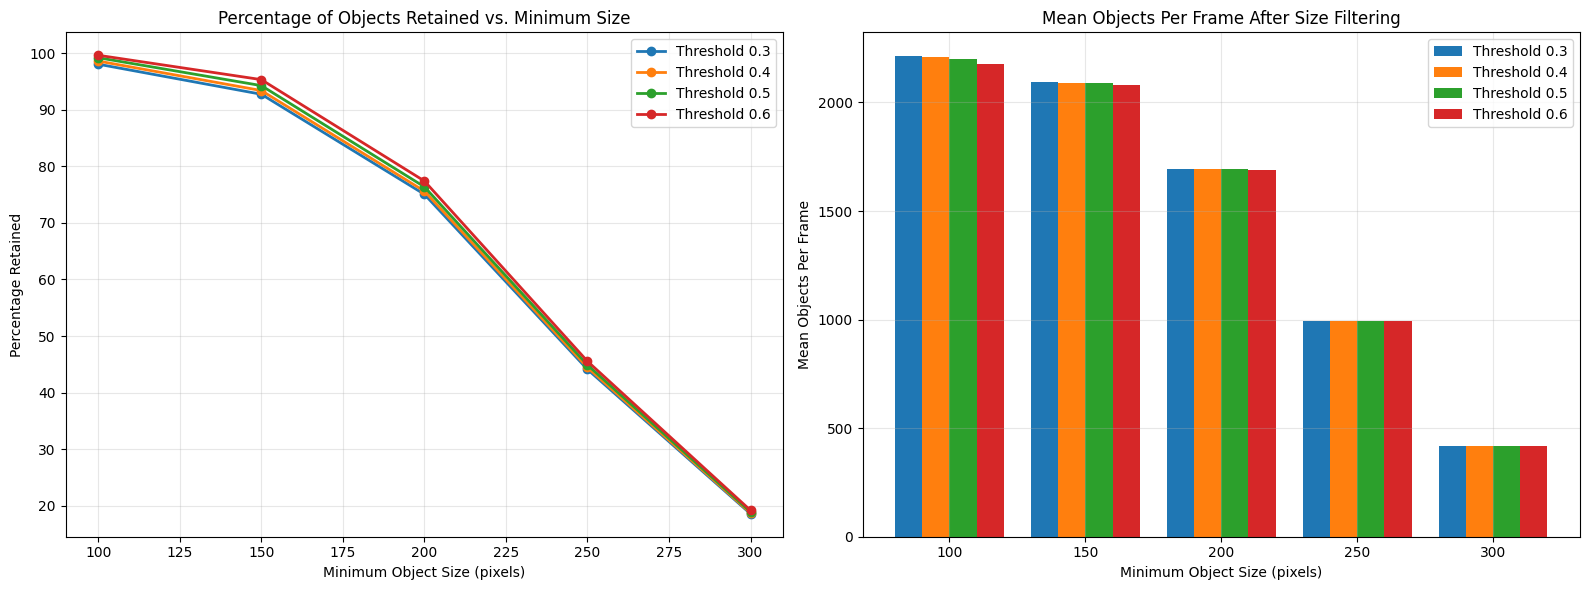

,Probability Threshold,Minimum Size,Total Objects,Objects Retained,Objects Removed,Percentage Retained,Percentage Removed,Mean Objects Per Frame,Mean Size
0,0.3,100,225701,221245,4456,98.025707,1.974293,2257.01,244.076539
1,0.3,150,225701,209252,16449,92.712039,7.287961,2257.01,244.076539
2,0.3,200,225701,169365,56336,75.039543,24.960457,2257.01,244.076539
3,0.3,250,225701,99547,126154,44.105697,55.894303,2257.01,244.076539
4,0.3,300,225701,41948,183753,18.585651,81.414349,2257.01,244.076539
5,0.4,100,224008,220824,3184,98.578622,1.421378,2240.08,245.285414
6,0.4,150,224008,209155,14853,93.369433,6.630567,2240.08,245.285414
7,0.4,200,224008,169346,54662,75.598193,24.401807,2240.08,245.285414
8,0.4,250,224008,99544,124464,44.437699,55.562301,2240.08,245.285414
9,0.4,300,224008,41947,182061,18.725671,81.274329,2240.08,245.285414


In [15]:
calculate_size_impact(preds)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from skimage import measure, morphology
from matplotlib.colors import ListedColormap
import pandas as pd
from tqdm.notebook import tqdm

def create_removed_objects_visualizer(preds, imgs_normal=None, prob_thresholds=[0.3, 0.4, 0.5, 0.6]):
    """
    Create an interactive tool to visualize objects that would be removed by size filtering.
    
    Parameters:
    -----------
    preds : list of numpy.ndarray
        List of segmentation predictions for different thresholds,
        each with shape (t, height, width)
    imgs_normal : numpy.ndarray, optional
        Original normalized images with shape (t, height, width)
    prob_thresholds : list
        List of probability thresholds used for segmentation
    """
    # Create colormaps for visualization
    np.random.seed(42)
    
    # Regular colormap for normal visualization
    random_colors = np.random.rand(255, 4)
    random_colors[:, 3] = 0.7  # Alpha value
    random_colors[0] = [0, 0, 0, 0]  # Background transparent
    random_cmap = ListedColormap(random_colors)
    
    # Red-focused colormap for removed objects
    removed_colors = np.zeros((255, 4))
    for i in range(1, 255):
        # Varying shades of red with some randomness
        removed_colors[i, 0] = 0.7 + 0.3 * np.random.rand()  # Red channel dominant
        removed_colors[i, 1] = 0.1 * np.random.rand()  # Low green
        removed_colors[i, 2] = 0.1 * np.random.rand()  # Low blue
        removed_colors[i, 3] = 0.7  # Alpha value
    removed_colors[0] = [0, 0, 0, 0]  # Background transparent
    removed_cmap = ListedColormap(removed_colors)
    
    # Get the number of frames and threshold options
    n_frames = preds[0].shape[0]
    
    # Create widgets
    frame_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=n_frames-1,
        step=1,
        description='Frame:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    threshold_dropdown = widgets.Dropdown(
        options=[(f'Threshold {t}', i) for i, t in enumerate(prob_thresholds)],
        value=0,
        description='Segmentation:',
        style={'description_width': 'initial'}
    )
    
    size_slider = widgets.IntSlider(
        value=200,
        min=0,
        max=1000,
        step=10,
        description='Min Size:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    show_original = widgets.Checkbox(
        value=True,
        description='Show Original Image',
        style={'description_width': 'initial'}
    )
    
    # Output widget
    out = widgets.Output()
    
    # Function to update the plot
    def update_plot(frame, threshold_idx, min_size, show_img):
        with out:
            out.clear_output(wait=True)
            
            # Get the current segmentation
            labels = preds[threshold_idx][frame].copy()
            
            # Get region properties
            regions = measure.regionprops(labels)
            
            # Create figure with 3 subplots in a row
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            
            # 1. Original segmentation
            if show_img and imgs_normal is not None:
                axes[0].imshow(imgs_normal[frame], cmap='gray')
                axes[0].imshow(labels, cmap=random_cmap, alpha=0.7)
            else:
                axes[0].imshow(labels, cmap=random_cmap)
                
            axes[0].set_title(f'Original Segmentation\n{len(regions)} Objects')
            axes[0].axis('off')
            
            # 2. Objects that would be removed
            # Create a mask that only includes objects smaller than min_size
            small_objects_mask = np.zeros_like(labels)
            removed_count = 0
            removed_sizes = []
            
            for region in regions:
                if region.area < min_size:
                    small_objects_mask[labels == region.label] = region.label
                    removed_count += 1
                    removed_sizes.append(region.area)
            
            if show_img and imgs_normal is not None:
                axes[1].imshow(imgs_normal[frame], cmap='gray')
                axes[1].imshow(small_objects_mask, cmap=removed_cmap, alpha=0.8)
            else:
                axes[1].imshow(small_objects_mask, cmap=removed_cmap)
                
            axes[1].set_title(f'Objects To Be Removed (< {min_size} px)\n{removed_count} Objects')
            axes[1].axis('off')
            
            # 3. Objects that would be kept
            # Create a mask that only includes objects larger than or equal to min_size
            large_objects_mask = np.zeros_like(labels)
            retained_count = 0
            retained_sizes = []
            
            for region in regions:
                if region.area >= min_size:
                    large_objects_mask[labels == region.label] = region.label
                    retained_count += 1
                    retained_sizes.append(region.area)
            
            if show_img and imgs_normal is not None:
                axes[2].imshow(imgs_normal[frame], cmap='gray')
                axes[2].imshow(large_objects_mask, cmap=random_cmap, alpha=0.7)
            else:
                axes[2].imshow(large_objects_mask, cmap=random_cmap)
                
            axes[2].set_title(f'Objects To Be Kept (≥ {min_size} px)\n{retained_count} Objects')
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Display statistics
            if regions:
                # Calculate statistics for removed objects
                if removed_sizes:
                    removed_min = min(removed_sizes)
                    removed_max = max(removed_sizes)
                    removed_mean = np.mean(removed_sizes)
                    removed_median = np.median(removed_sizes)
                else:
                    removed_min = removed_max = removed_mean = removed_median = 0
                
                # Calculate statistics for retained objects
                if retained_sizes:
                    retained_min = min(retained_sizes)
                    retained_max = max(retained_sizes)
                    retained_mean = np.mean(retained_sizes)
                    retained_median = np.median(retained_sizes)
                else:
                    retained_min = retained_max = retained_mean = retained_median = 0
                
                # Create summary table
                summary = pd.DataFrame({
                    'Category': ['Objects To Be Removed', 'Objects To Be Kept', 'All Objects'],
                    'Count': [removed_count, retained_count, len(regions)],
                    'Percentage': [
                        f'{removed_count/len(regions)*100:.1f}%' if len(regions) > 0 else '0%',
                        f'{retained_count/len(regions)*100:.1f}%' if len(regions) > 0 else '0%',
                        '100%'
                    ],
                    'Min Size': [removed_min if removed_sizes else '-', 
                                retained_min if retained_sizes else '-',
                                min([r.area for r in regions]) if regions else '-'],
                    'Max Size': [removed_max if removed_sizes else '-', 
                                retained_max if retained_sizes else '-',
                                max([r.area for r in regions]) if regions else '-'],
                    'Mean Size': [f'{removed_mean:.1f}' if removed_sizes else '-', 
                                f'{retained_mean:.1f}' if retained_sizes else '-',
                                f'{np.mean([r.area for r in regions]):.1f}' if regions else '-'],
                    'Median Size': [f'{removed_median:.1f}' if removed_sizes else '-', 
                                   f'{retained_median:.1f}' if retained_sizes else '-',
                                   f'{np.median([r.area for r in regions]):.1f}' if regions else '-']
                })
                
                display(summary)
                
                # Show histogram of sizes with removal threshold
                if len(regions) > 1:
                    plt.figure(figsize=(12, 5))
                    areas = [r.area for r in regions]
                    
                    # Calculate bins with a logarithmic scale if there's enough range
                    if max(areas) / max(1, min(areas)) > 10:
                        bins = np.logspace(np.log10(max(1, min(areas))), np.log10(max(areas)), 30)
                        plt.xscale('log')
                    else:
                        bins = 30
                    
                    # Plot histogram with two colors
                    plt.hist([a for a in areas if a < min_size], bins=bins, alpha=0.7, color='red', 
                             label=f'To Be Removed (< {min_size} px)')
                    plt.hist([a for a in areas if a >= min_size], bins=bins, alpha=0.7, color='blue', 
                             label=f'To Be Kept (≥ {min_size} px)')
                    
                    plt.axvline(x=min_size, color='black', linestyle='--', 
                                label=f'Min Size = {min_size}')
                    
                    plt.title('Object Size Distribution')
                    plt.xlabel('Object Size (pixels)')
                    plt.ylabel('Count')
                    plt.legend()
                    plt.grid(True, alpha=0.3)
                    plt.tight_layout()
                    plt.show()
            else:
                print("No objects detected in this frame.")
            
            # Show examples of objects near the threshold
            if regions and len(regions) > 1:
                # Sort regions by area
                sorted_regions = sorted(regions, key=lambda r: r.area)
                
                # Find objects near the threshold (both below and above)
                near_threshold = []
                
                # Objects just below the threshold
                below = [r for r in sorted_regions if r.area < min_size]
                if below:
                    # Take the largest ones below threshold
                    near_threshold.extend(below[-min(3, len(below)):])
                
                # Objects just above the threshold
                above = [r for r in sorted_regions if r.area >= min_size]
                if above:
                    # Take the smallest ones above threshold
                    near_threshold.extend(above[:min(3, len(above))])
                
                # Sort by area
                near_threshold.sort(key=lambda r: r.area)
                
                if near_threshold:
                    fig, axes = plt.subplots(1, len(near_threshold), figsize=(15, 5))
                    if len(near_threshold) == 1:
                        axes = [axes]  # Make it iterable when only one subplot
                    
                    for i, region in enumerate(near_threshold):
                        # Get bounding box with padding
                        minr, minc, maxr, maxc = region.bbox
                        pad = 5
                        minr = max(0, minr - pad)
                        minc = max(0, minc - pad)
                        maxr = min(labels.shape[0], maxr + pad)
                        maxc = min(labels.shape[1], maxc + pad)
                        
                        # Create mask for this object
                        object_mask = np.zeros_like(labels)
                        object_mask[labels == region.label] = 1
                        
                        # Display original image crop if available
                        if show_img and imgs_normal is not None:
                            axes[i].imshow(imgs_normal[frame][minr:maxr, minc:maxc], cmap='gray')
                            axes[i].imshow(object_mask[minr:maxr, minc:maxc], cmap='jet', alpha=0.7)
                        else:
                            axes[i].imshow(object_mask[minr:maxr, minc:maxc], cmap='jet')
                        
                        # Set title with object info
                        status = "REMOVED" if region.area < min_size else "KEPT"
                        color = "red" if status == "REMOVED" else "green"
                        axes[i].set_title(f'Size: {region.area} px\n{status}', 
                                         color=color, fontsize=12)
                        axes[i].axis('off')
                    
                    plt.suptitle(f'Examples of Objects Near Size Threshold ({min_size} px)', fontsize=14)
                    plt.tight_layout()
                    plt.subplots_adjust(top=0.85)
                    plt.show()
    
    # Connect widgets to update function
    def on_change(change):
        update_plot(
            frame_slider.value,
            threshold_dropdown.value,
            size_slider.value,
            show_original.value
        )
    
    frame_slider.observe(on_change, names='value')
    threshold_dropdown.observe(on_change, names='value')
    size_slider.observe(on_change, names='value')
    show_original.observe(on_change, names='value')
    
    # Layout controls
    controls = widgets.HBox([frame_slider, threshold_dropdown, size_slider, show_original])
    
    # Initial plot
    update_plot(
        frame_slider.value,
        threshold_dropdown.value,
        size_slider.value,
        show_original.value
    )
    
    # Display controls and output
    display(controls)
    display(out)

def create_removal_impact_animation(preds, frame_idx=0, threshold_idx=0, size_range=(0, 500, 10), 
                                   imgs_normal=None, prob_thresholds=[0.3, 0.4, 0.5, 0.6]):
    """
    Create an animation showing how different minimum size thresholds affect object removal.
    
    Parameters:
    -----------
    preds : list of numpy.ndarray
        List of segmentation predictions for different thresholds
    frame_idx : int
        Frame index to use for visualization
    threshold_idx : int
        Index of the segmentation threshold to use
    size_range : tuple
        (min_size, max_size, step) for size threshold range
    imgs_normal : numpy.ndarray, optional
        Original normalized images
    prob_thresholds : list
        List of probability thresholds used for segmentation
    """
    # Get the selected segmentation
    labels = preds[threshold_idx][frame_idx].copy()
    
    # Get region properties
    regions = measure.regionprops(labels)
    
    # Size thresholds to test
    min_sizes = list(range(size_range[0], size_range[1] + 1, size_range[2]))
    
    # Create widgets
    size_slider = widgets.IntSlider(
        value=min_sizes[0],
        min=min_sizes[0],
        max=min_sizes[-1],
        step=size_range[2],
        description='Min Size:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    play_button = widgets.Play(
        value=min_sizes[0],
        min=min_sizes[0],
        max=min_sizes[-1],
        step=size_range[2],
        interval=200,  # milliseconds between frames
        description="Play",
        disabled=False
    )
    
    # Link play button to slider
    widgets.jslink((play_button, 'value'), (size_slider, 'value'))
    
    show_original = widgets.Checkbox(
        value=True,
        description='Show Original Image',
        style={'description_width': 'initial'}
    )
    
    # Output widget
    out = widgets.Output()
    
    # Function to update the plot
    def update_plot(min_size, show_img):
        with out:
            out.clear_output(wait=True)
            
            # Calculate statistics
            areas = [r.area for r in regions]
            removed_count = sum(area < min_size for area in areas)
            removed_pct = removed_count / len(areas) * 100 if areas else 0
            
            # Create figure
            fig, axes = plt.subplots(1, 2, figsize=(16, 7))
            
            # Display original or filtered image
            if show_img and imgs_normal is not None:
                axes[0].imshow(imgs_normal[frame_idx], cmap='gray')
            
            # Create a mask of objects to be removed (smaller than min_size)
            small_objects_mask = np.zeros_like(labels)
            for region in regions:
                if region.area < min_size:
                    small_objects_mask[labels == region.label] = 1
            
            # Show removed objects in red
            removed_mask = np.ma.masked_where(small_objects_mask == 0, small_objects_mask)
            axes[0].imshow(removed_mask, cmap='RdPu', alpha=0.8, vmin=0, vmax=1)
            
            # Title and axes
            axes[0].set_title(f'Objects To Be Removed (< {min_size} px)\n'
                             f'{removed_count} objects ({removed_pct:.1f}% of total)',
                             fontsize=12)
            axes[0].axis('off')
            
            # Plot histogram with removal threshold
            areas = [r.area for r in regions]
            
            # Calculate bins with a logarithmic scale if there's enough range
            if max(areas) / max(1, min(areas)) > 10:
                bins = np.logspace(np.log10(max(1, min(areas))), np.log10(max(areas)), 30)
                axes[1].set_xscale('log')
            else:
                bins = 30
            
            # Plot histogram with two colors
            axes[1].hist([a for a in areas if a < min_size], bins=bins, alpha=0.7, color='red', 
                     label=f'To Be Removed (< {min_size} px)')
            axes[1].hist([a for a in areas if a >= min_size], bins=bins, alpha=0.7, color='blue', 
                     label=f'To Be Kept (≥ {min_size} px)')
            
            # Add vertical line for current threshold
            axes[1].axvline(x=min_size, color='black', linestyle='--', 
                        label=f'Min Size = {min_size}')
            
            # Add text showing counts
            text = (f"Total Objects: {len(areas)}\n"
                   f"Objects Removed: {removed_count} ({removed_pct:.1f}%)\n"
                   f"Objects Kept: {len(areas) - removed_count} ({100 - removed_pct:.1f}%)")
            
            axes[1].text(0.95, 0.95, text, transform=axes[1].transAxes, 
                     verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            
            axes[1].set_title('Object Size Distribution', fontsize=12)
            axes[1].set_xlabel('Object Size (pixels)')
            axes[1].set_ylabel('Count')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
    
    # Connect widgets to update function
    def on_change(change):
        update_plot(size_slider.value, show_original.value)
    
    size_slider.observe(on_change, names='value')
    show_original.observe(on_change, names='value')
    
    # Layout controls
    controls = widgets.HBox([play_button, size_slider, show_original])
    
    # Display info about the current frame and threshold
    print(f"Visualizing Frame {frame_idx} with Segmentation Threshold {prob_thresholds[threshold_idx]}")
    
    # Initial plot
    update_plot(size_slider.value, show_original.value)
    
    # Display controls and output
    display(controls)
    display(out)

# Example usage:
create_removed_objects_visualizer(preds, imgs_normal)
# create_removal_impact_animation(preds, frame_idx=0, threshold_idx=0, size_range=(0, 500, 10), imgs_normal=imgs_normal)

Output()

In [7]:
create_removal_impact_animation(preds, frame_idx=0, threshold_idx=0, size_range=(0, 500, 10), imgs_normal=imgs_normal)

Visualizing Frame 0 with Segmentation Threshold 0.3


Output()

In [13]:
tiff.imwrite('Exp07_test_mask_no_filter', preds[2].astype(np.uint16))

In [8]:
help(model.predict_instances)

Help on method _predict_instances_generator in module stardist.models.base:

_predict_instances_generator(img, axes=None, normalizer=None, sparse=True, prob_thresh=None, nms_thresh=None, scale=None, n_tiles=None, show_tile_progress=True, verbose=False, return_labels=True, predict_kwargs=None, nms_kwargs=None, overlap_label=None, return_predict=False) method of stardist.models.model2d.StarDist2D instance
    Predict instance segmentation from input image.
    
    Parameters
    ----------
    img : :class:`numpy.ndarray`
        Input image
    axes : str or None
        Axes of the input ``img``.
        ``None`` denotes that axes of img are the same as denoted in the config.
    normalizer : :class:`csbdeep.data.Normalizer` or None
        (Optional) normalization of input image before prediction.
        Note that the default (``None``) assumes ``img`` to be already normalized.
    sparse: bool
        If true, aggregate probabilities/distances sparsely during tiled
        predicti

In [9]:
model.config

Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=33, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=32, grid=(2, 2), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=[3, 3], unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=[2, 2], unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_prefix='', net_conv_after_unet=128, net_input_shape=[None, None, 1], net_mask_shape=[None, None, 1], train_shape_completion=False, train_completion_crop=32, train_patch_size=[256, 256], train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=[1, 0.2], train_class_weights=(1, 1), train_epochs=800, train_steps_per_epoch=400, train_learning_rate=0.0003, train_batch_size=8, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 80, 'min_delta': 0}, 

In [ ]:
Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=33, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=32, grid=(2, 2), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=[3, 3], unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=[2, 2], unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_prefix='', net_conv_after_unet=128, net_input_shape=[None, None, 1], net_mask_shape=[None, None, 1], train_shape_completion=False, train_completion_crop=32, train_patch_size=[256, 256], train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=[1, 0.2], train_class_weights=(1, 1), train_epochs=800, train_steps_per_epoch=400, train_learning_rate=0.0003, train_batch_size=8, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 80, 'min_delta': 0}, use_gpu=False)